In [1]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import comb
from scipy.stats import norm
import seaborn as sns
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
sns.set()
import pickle
from scipy.stats import wilcoxon, ttest_rel, friedmanchisquare
import pathlib
from pathlib import Path

In [2]:
output_dir = pathlib.Path.home() / "BO" / "models" / "X04"
output_dir_gm = pathlib.Path.home() / "BO" / "models" / "X04_gm"
output_dir_hs = pathlib.Path.home() / "BO" / "models" / "X04_hs2"
output_dir_t = pathlib.Path.home() / "BO" / "models" / "X04_t"

- $\sigma=2$
- $\epsilon \sim \mathcal{N} (0, \sigma^2)$
- Student t: $\sigma \sqrt{\frac{\nu-2}{\nu}} T_{\nu}$, $\nu=4$, so the marginal standard derviation is $\sigma$.
- Gaussian Mixture: $(1-\pi) \mathcal{N(0, \tilde{\sigma}^2)} + \pi \mathcal{N}(0, (c \tilde{\sigma})^2)$. $\pi=0.1, c=5, \tilde{\sigma}=\frac{\sigma}{\sqrt{(1-\pi)+ \pi c^2}}$.
- Heteroscedastic: $\mathcal{N}(0, \sigma^2 \frac{\lambda(X)}{Z})$, $\lambda(x) = 1+ \rho \exp \{\frac{-\|x-x^*\|^2}{\kappa d}\}$. $Z = \mathcal{E}[\lambda(U)]$, $U\sim \text{Unif}([0,1]^d)$, estimated via Monte Carlo. Here I choose $\rho=\frac{1}{4}$ and $\kappa=4$.

In [3]:
# patch optimum for special function
PATCH_OPTIMA = {
    ("hartmann3", 3): 3.8627797869493365,
    ("hartmann4", 4): 3.134494141221212,
    ("hartmann6", 6): (2.58 + 3.32236801141551) / 1.94,
    ("michalewicz", 5): 4.687658,
    ("michalewicz", 10): 9.6601517,
    ("shekel", 4): 10.536443153482534,
}


def patch_missing_simple_regret(
    df,
    *,
    optima=PATCH_OPTIMA,
    regret_col="final_simple_regret",
    best_latent_col="final_best_latent",
    verbose=True,
):
    """
    Patch only rows whose final_simple_regret is missing.
    """
    df = df.copy()

    if regret_col not in df.columns:
        raise KeyError(f"Missing column: {regret_col}")
    if best_latent_col not in df.columns:
        raise KeyError(f"Missing column: {best_latent_col}")

    # Normalize types
    df["function"] = df["function"].astype(str)
    df["dimension"] = df["dimension"].astype(int)

    key = list(zip(df["function"], df["dimension"]))
    df["_optimum_key"] = key

    missing = df[regret_col].isna()
    patchable = missing & df["_optimum_key"].map(lambda k: k in optima)

    unknown_missing = (
        df.loc[missing & ~patchable, ["batch", "function", "dimension"]]
        .drop_duplicates()
        .sort_values(["batch", "function", "dimension"])
        if "batch" in df.columns
        else df.loc[missing & ~patchable, ["function", "dimension"]]
             .drop_duplicates()
             .sort_values(["function", "dimension"])
    )

    if not unknown_missing.empty:
        raise ValueError(
            "Some rows have missing final_simple_regret but are not in PATCH_OPTIMA:\n"
            + unknown_missing.to_string(index=False)
        )

    df["true_optimum_patch"] = np.nan
    df.loc[patchable, "true_optimum_patch"] = df.loc[patchable, "_optimum_key"].map(optima)

    df.loc[patchable, regret_col] = (
        df.loc[patchable, "true_optimum_patch"]
        - df.loc[patchable, best_latent_col]
    )

    # Sanity check: regret should not be meaningfully negative.
    bad_negative = df.loc[df[regret_col] < -1e-8, ["batch", "function", "dimension", regret_col]] \
        if "batch" in df.columns else \
        df.loc[df[regret_col] < -1e-8, ["function", "dimension", regret_col]]

    if not bad_negative.empty:
        raise ValueError(
            "Some patched regrets are negative. This usually means an optimum value is wrong:\n"
            + bad_negative.head(20).to_string(index=False)
        )

    if verbose:
        print(f"Rows patched: {int(patchable.sum())}")
        print(f"Remaining missing {regret_col}: {int(df[regret_col].isna().sum())}")
        print("Patched tasks:")
        print(
            df.loc[patchable, ["function", "dimension"]]
              .drop_duplicates()
              .sort_values(["function", "dimension"])
              .to_string(index=False)
        )

    return df.drop(columns=["_optimum_key"])

## Gaussian Noise

In [4]:

# ------------------------------------------------------------------
# 1) Load and combine the 3 Gaussian result CSVs
# ------------------------------------------------------------------

def load_results(folder=output_dir, noise="gaussian"):
    files = sorted(Path(folder).glob(f"s0*_{noise}_experiment_results_ai_2.csv"))
    if not files:
        raise FileNotFoundError(
            f"No s0*_{noise}_experiment_results_ai_2.csv files found in {folder}."
        )

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["batch"] = f.name.split(f"_{noise}_experiment_results_ai_2.csv")[0]
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    df["alpha"] = (
        df["alpha"]
        .astype(str)
        .str.strip()
        .replace({
            "1.0": "1",
            "1": "1",
            "0.5": "0.5",
            "hw": "hw",
            "Tempered": "hw",
            "tempered": "hw",
        })
    )

    df["g"] = (
        df["g"]
        .astype(str)
        .str.strip()
        .replace({"0.0": "0", "1.0": "1", "2.0": "2"})
    )

    return df

TASK_COLS = ["function", "dimension"]


def average_over_seeds(df, metric, task_cols=TASK_COLS):
    out = (
        df.dropna(subset=[metric])
          .groupby(task_cols + ["alpha", "g"], as_index=False)[metric]
          .mean()
    )
    return out


def _competition_table(
    avg_df,
    *,
    condition_col,
    condition_value,
    compare_col,
    compare_values,
    metric,
    larger_is_better,
    task_cols=TASK_COLS,
):
    sub = avg_df[avg_df[condition_col].astype(str) == str(condition_value)].copy()

    compare_values = [str(x) for x in compare_values]

    wide = sub.pivot(
        index=task_cols,
        columns=compare_col,
        values=metric,
    )

    wide = wide.reindex(columns=compare_values)

    incomplete = wide[compare_values].isna().any(axis=1)
    if incomplete.any():
        raise ValueError(
            f"Found {incomplete.sum()} incomplete paired tasks for "
            f"{condition_col}={condition_value}.\n"
            + wide.loc[incomplete].to_string()
        )

    wide = wide[compare_values]

    row_best = wide.max(axis=1) if larger_is_better else wide.min(axis=1)
    row_range = wide.max(axis=1) - wide.min(axis=1)

    ranks = wide.rank(
        axis=1,
        method="average",
        ascending=not larger_is_better,
    )

    if larger_is_better:
        margins = wide.sub(row_best, axis=0)
    else:
        margins = wide.rsub(row_best, axis=0)

    norm_margins = (
        margins
        .div(row_range.replace(0, np.nan), axis=0)
        .fillna(0.0)
    )

    best_mask = wide.eq(row_best, axis=0)
    n_best = best_mask.sum(axis=1)

    strict_mask = best_mask & n_best.eq(1).to_numpy()[:, None]
    strict_wins = strict_mask.sum(axis=0).astype(int)

    win_share = best_mask.div(n_best, axis=0)
    win_share_count = win_share.sum(axis=0)

    out = pd.DataFrame({
        compare_col: wide.columns.astype(str),
        "wins": strict_wins.values,
        "strict_win_rate": (strict_wins / len(wide)).values,
        "win_share_count": win_share_count.values,
        "win_share_rate": (win_share_count / len(wide)).values,
        "avg_rank": ranks.mean(axis=0).values,
        "avg_margin_to_row_best": margins.mean(axis=0).values,
        "avg_norm_margin_range": norm_margins.mean(axis=0).values,
        "n_tasks": len(wide),
    })

    return out, wide


def wilcoxon_hw_vs_1(wide, metric):
    """
    One-sided paired Wilcoxon test for hw being better than alpha=1.

    For regret: lower is better, so diff = regret_1 - regret_hw.
    For best-observed: higher is better, so diff = best_hw - best_1.
    """
    if set(wide.columns) != {"hw", "1"}:
        return None

    if metric == "final_best_observed":
        diff = wide["hw"] - wide["1"]
    else:
        diff = wide["1"] - wide["hw"]

    nonzero = diff[diff != 0]

    if len(nonzero) == 0:
        return {
            "pvalue": 1.0,
            "n_pairs": len(diff),
            "n_nonzero": 0,
        }

    stat = wilcoxon(nonzero, alternative="greater")

    return {
        "statistic": stat.statistic,
        "pvalue": stat.pvalue,
        "n_pairs": len(diff),
        "n_nonzero": len(nonzero),
    }


def alpha_table(df, g, alphas=("hw", "1"), metric="final_simple_regret"):
    avg = average_over_seeds(df, metric)
    larger_is_better = metric == "final_best_observed"

    tbl, wide = _competition_table(
        avg,
        condition_col="g",
        condition_value=str(g),
        compare_col="alpha",
        compare_values=alphas,
        metric=metric,
        larger_is_better=larger_is_better,
    )

    tbl = tbl[[
        "alpha",
        "wins",
        "strict_win_rate",
        "avg_rank",
        "avg_margin_to_row_best",
        "avg_norm_margin_range",
        "n_tasks",
    ]]

    test = None
    if len(alphas) == 2 and set(alphas) == {"hw", "1"}:
        wtest = wilcoxon_hw_vs_1(wide, metric)
        test = (
            f"Wilcoxon one-sided ({metric}): "
            f"p = {wtest['pvalue']:.5g} | hw better than 1 | "
            f"n_pairs = {wtest['n_pairs']}, n_nonzero = {wtest['n_nonzero']}"
        )

    return tbl, test

In [5]:
df = load_results()
df = patch_missing_simple_regret(df)
df.to_csv("gaussian_results.csv", index=False)
for g in ["0", "1", "2"]:
    print(f"\n## Alpha comparison given g={g} | metric = regret")
    tbl, test = alpha_table(df, g=g, alphas=["hw", "1"], metric="final_simple_regret")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

    print(f"\n## Alpha comparison given g={g} | metric = best observed")
    tbl, test = alpha_table(df, g=g, alphas=["hw", "1"], metric="final_best_observed")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

Rows patched: 180
Remaining missing final_simple_regret: 0
Patched tasks:
   function  dimension
  hartmann3          3
  hartmann4          4
  hartmann6          6
michalewicz          5
michalewicz         10
     shekel          4

## Alpha comparison given g=0 | metric = regret
Wilcoxon one-sided (final_simple_regret): p = 0.32391 | hw better than 1 | n_pairs = 61, n_nonzero = 56
| alpha   |   wins |   strict_win_rate |   avg_rank |   avg_margin_to_row_best |   avg_norm_margin_range |   n_tasks |
|:--------|-------:|------------------:|-----------:|-------------------------:|------------------------:|----------:|
| hw      |     31 |          0.508197 |    1.45082 |                 -15.0716 |               -0.409836 |        61 |
| 1       |     25 |          0.409836 |    1.54918 |                 -81.87   |               -0.508197 |        61 |

## Alpha comparison given g=0 | metric = best observed
Wilcoxon one-sided (final_best_observed): p = 0.29014 | hw better than 1 | n_pai

## T-Distributed Noise

In [6]:
t_df = load_results(folder= output_dir_t ,noise="student_t")
t_df = patch_missing_simple_regret(t_df)
t_df.to_csv("t_results.csv", index=False)
for g in ["0", "1", "2"]:
    print(f"\n## Alpha comparison given g={g} | metric = regret")
    tbl, test = alpha_table(t_df, g=g, alphas=["hw",  "1"], metric="final_simple_regret")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

    print(f"\n## Alpha comparison given g={g} | metric = best observed")
    tbl, test = alpha_table(t_df, g=g, alphas=["hw", "1"], metric="final_best_observed")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))



Rows patched: 180
Remaining missing final_simple_regret: 0
Patched tasks:
   function  dimension
  hartmann3          3
  hartmann4          4
  hartmann6          6
michalewicz          5
michalewicz         10
     shekel          4

## Alpha comparison given g=0 | metric = regret
Wilcoxon one-sided (final_simple_regret): p = 0.45729 | hw better than 1 | n_pairs = 61, n_nonzero = 57
| alpha   |   wins |   strict_win_rate |   avg_rank |   avg_margin_to_row_best |   avg_norm_margin_range |   n_tasks |
|:--------|-------:|------------------:|-----------:|-------------------------:|------------------------:|----------:|
| hw      |     31 |          0.508197 |    1.45902 |                -48.0519  |               -0.42623  |        61 |
| 1       |     26 |          0.42623  |    1.54098 |                 -8.11514 |               -0.508197 |        61 |

## Alpha comparison given g=0 | metric = best observed
Wilcoxon one-sided (final_best_observed): p = 0.40119 | hw better than 1 | n_pai

## Gaussian Mixture

In [7]:
gm_df = load_results(folder= output_dir_gm ,noise="gaussian_mixture")
gm_df = patch_missing_simple_regret(gm_df)
gm_df.to_csv("gm_results.csv", index=False)
for g in ["0", "1", "2"]:
    print(f"\n## Alpha comparison given g={g} | metric = regret")
    tbl, test = alpha_table(gm_df, g=g, alphas=["hw",  "1"], metric="final_simple_regret")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

    print(f"\n## Alpha comparison given g={g} | metric = best observed")
    tbl, test = alpha_table(gm_df, g=g, alphas=["hw", "1"], metric="final_best_observed")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

Rows patched: 180
Remaining missing final_simple_regret: 0
Patched tasks:
   function  dimension
  hartmann3          3
  hartmann4          4
  hartmann6          6
michalewicz          5
michalewicz         10
     shekel          4

## Alpha comparison given g=0 | metric = regret
Wilcoxon one-sided (final_simple_regret): p = 0.12692 | hw better than 1 | n_pairs = 61, n_nonzero = 60
| alpha   |   wins |   strict_win_rate |   avg_rank |   avg_margin_to_row_best |   avg_norm_margin_range |   n_tasks |
|:--------|-------:|------------------:|-----------:|-------------------------:|------------------------:|----------:|
| hw      |     35 |          0.57377  |    1.41803 |                -51.8048  |               -0.409836 |        61 |
| 1       |     25 |          0.409836 |    1.58197 |                 -6.11413 |               -0.57377  |        61 |

## Alpha comparison given g=0 | metric = best observed
Wilcoxon one-sided (final_best_observed): p = 0.075472 | hw better than 1 | n_pa

# Heteroscedasticity

In [8]:
hs_df = load_results(folder= output_dir_hs ,noise="heteroscedastic")
hs_df = patch_missing_simple_regret(hs_df)
hs_df.to_csv("hs_results.csv", index=False)
for g in ["0", "1", "2"]:
    print(f"\n## Alpha comparison given g={g} | metric = regret")
    tbl, test = alpha_table(hs_df, g=g, alphas=["hw",  "1"], metric="final_simple_regret")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

    print(f"\n## Alpha comparison given g={g} | metric = best observed")
    tbl, test = alpha_table(hs_df, g=g, alphas=["hw", "1"], metric="final_best_observed")
    if test:
        print(test)
    print(tbl.to_markdown(index=False))

Rows patched: 180
Remaining missing final_simple_regret: 0
Patched tasks:
   function  dimension
  hartmann3          3
  hartmann4          4
  hartmann6          6
michalewicz          5
michalewicz         10
     shekel          4

## Alpha comparison given g=0 | metric = regret
Wilcoxon one-sided (final_simple_regret): p = 0.80387 | hw better than 1 | n_pairs = 61, n_nonzero = 58
| alpha   |   wins |   strict_win_rate |   avg_rank |   avg_margin_to_row_best |   avg_norm_margin_range |   n_tasks |
|:--------|-------:|------------------:|-----------:|-------------------------:|------------------------:|----------:|
| hw      |     25 |          0.409836 |    1.56557 |                 -9.40394 |               -0.540984 |        61 |
| 1       |     33 |          0.540984 |    1.43443 |                -29.3406  |               -0.409836 |        61 |

## Alpha comparison given g=0 | metric = best observed
Wilcoxon one-sided (final_best_observed): p = 0.63518 | hw better than 1 | n_pai

In [9]:
df

,function,dimension,alpha,g,noise_model,noise_std,seed,final_best_observed,final_best_latent,final_observed_gap,final_simple_regret,batch,true_optimum_patch
0,sphere,5,1,0,gaussian,2.0,0,6.229968,-0.187999,-6.229968,0.187999,s01_batch1,NaN
1,sphere,5,1,0,gaussian,2.0,1,0.611255,-1.656010,-0.611255,1.656010,s01_batch1,NaN
2,sphere,5,1,0,gaussian,2.0,2,-5.969142,-6.152471,5.969142,6.152471,s01_batch1,NaN
3,sphere,5,1,0,gaussian,2.0,3,2.567576,-0.686956,-2.567576,0.686956,s01_batch1,NaN
4,sphere,5,1,0,gaussian,2.0,4,2.886143,-0.754377,-2.886143,0.754377,s01_batch1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,styblinski_tang,10,hw,2,gaussian,2.0,0,-62.523476,-60.908416,62.523476,60.908416,s03_batch3,NaN
1826,styblinski_tang,10,hw,2,gaussian,2.0,1,-109.135478,-105.759073,109.135478,105.759073,s03_batch3,NaN
1827,styblinski_tang,10,hw,2,gaussian,2.0,2,-144.644130,-145.377190,144.644130,145.377190,s03_batch3,NaN
1828,styblinski_tang,10,hw,2,gaussian,2.0,3,-110.889824,-111.018364,110.889824,111.018364,s03_batch3,NaN


# Visualization

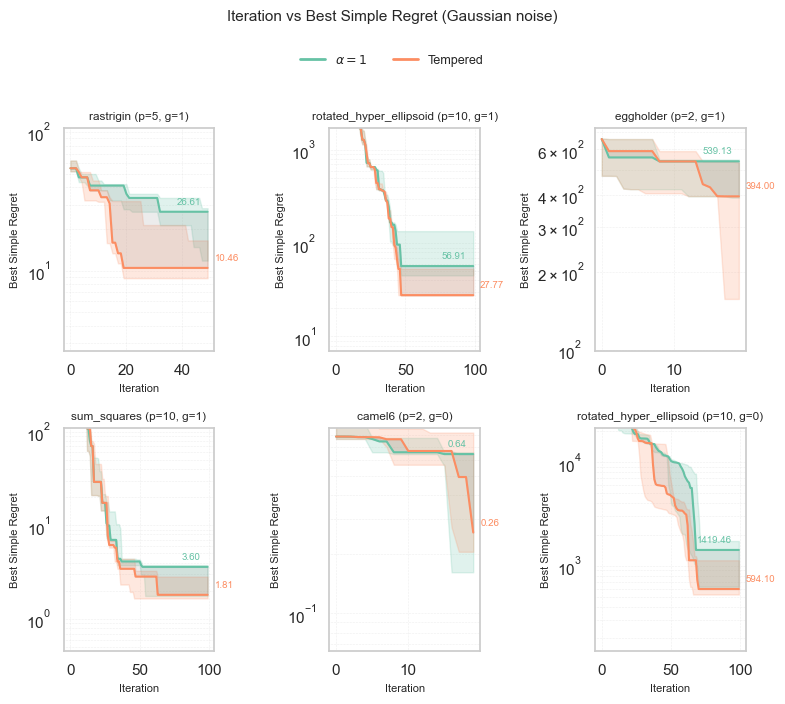

In [13]:
from matplotlib.lines import Line2D
from collections import defaultdict

# Load the raw experiment pickle files (Gaussian noise)
files = [
    's01_batch1_gaussian_experiment_results_ai_2.pkl',
    's02_batch2_gaussian_experiment_results_ai_2.pkl',
    's03_batch3_gaussian_experiment_results_ai_2.pkl'
]
results = []
for fn in files:
    with open(fn, 'rb') as f:
        results += pickle.load(f)

# Known optima used to patch missing simple regrets
PATCH_OPTIMA = {
    ("hartmann3", 3): 3.8627797869493365,
    ("hartmann4", 4): 3.134494141221212,
    ("hartmann6", 6): (2.58 + 3.32236801141551) / 1.94,
    ("michalewicz", 5): 4.687658,
    ("michalewicz", 10): 9.6601517,
    ("shekel", 4): 10.536443153482534,
}

# Patch missing simple regrets using best_so_far_latent and the known optima
for r in results:
    if r['simple_regret'] is None:
        opt = PATCH_OPTIMA[(r['function'], r['dimension'])]
        best_latent = np.asarray(r['best_so_far_latent'], dtype=float)
        simple_regret = opt - best_latent
        r['simple_regret'] = simple_regret.tolist()
        r['final_simple_regret'] = float(simple_regret[-1])

# Group runs by (function, dimension, g, alpha)
runs = defaultdict(list)
for r in results:
    key = (r['function'], r['dimension'], str(r['g']), str(r['alpha']))
    runs[key].append(r)

# Helper to compute median and interquartile regret trajectories
def compute_curves(func, dim, g, alpha):
    arrs = []
    for run in runs[(func, dim, g, alpha)]:
        r = np.asarray(run['simple_regret'], dtype=float)
        warm = max(2 * dim, 5)  # drop the first max(2d, 5) iterations
        arrs.append(r[warm:])
    arrs = np.array(arrs)
    min_len = min(len(a) for a in arrs)
    arrs = arrs[:, :min_len]
    median = np.median(arrs, axis=0)
    q25    = np.percentile(arrs, 25, axis=0)
    q75    = np.percentile(arrs, 75, axis=0)
    return median, q25, q75

# Choose six representative functions: four g=1 cases and two g=0 cases
selected = [
    ('rastrigin', 5, '1'),             # d=5
    ('rotated_hyper_ellipsoid', 10, '1'), # d=10
    ('eggholder', 2, '1'),             # d=2
    ('sum_squares', 10, '1'),          # d=10
    ('camel6', 2, '0'),                # d=2
    ('rotated_hyper_ellipsoid', 10, '0'),
]

# Set up seaborn style and plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(8, 6.5))
axes = axes.flatten()
colors = sns.color_palette("Set2", 2)

for idx, (func, dim, g) in enumerate(selected):
    ax = axes[idx]
    med_b, q25_b, q75_b = compute_curves(func, dim, g, '1.0')
    med_t, q25_t, q75_t = compute_curves(func, dim, g, 'hw')
    steps = np.arange(len(med_b))

    # Plot baseline and tempered curves with IQR shading
    ax.fill_between(steps, q25_b, q75_b, color=colors[0], alpha=0.2)
    ax.plot(steps, med_b, color=colors[0], lw=1.5)
    ax.fill_between(steps, q25_t, q75_t, color=colors[1], alpha=0.2)
    ax.plot(steps, med_t, color=colors[1], lw=1.5)

    # Shade the area between the two median curves
    lower = np.minimum(med_b, med_t)
    upper = np.maximum(med_b, med_t)
    ax.fill_between(steps, lower, upper, color='gray', alpha=0.15)

    # Annotate final median values
    ax.annotate(f"{med_b[-1]:.2f}", (steps[-1], med_b[-1]),
                xytext=(-5, 5), textcoords='offset points',
                color=colors[0], fontsize=7, ha='right')
    ax.annotate(f"{med_t[-1]:.2f}", (steps[-1], med_t[-1]),
                xytext=(5, 5), textcoords='offset points',
                color=colors[1], fontsize=7, ha='left')

    # Titles and axes
    ax.set_title(f"{func} (p={dim}, g={g})", fontsize=8.5)
    ax.set_xlabel('Iteration', fontsize=8)
    ax.set_ylabel('Best Simple Regret', fontsize=8)
    ax.set_yscale('log')

    # Crop the y-axis to reduce white space
    final_min = min(med_b[-1], med_t[-1])
    final_max = max(med_b[-1], med_t[-1])
    initial_max = max(med_b[0], med_t[0])
    ratio = initial_max / final_max if final_max > 0 else 1.0
    y_lower = max(final_min / 4, 1e-12)
    if ratio > 100:
        y_upper = final_max * 30
    elif ratio > 50:
        y_upper = final_max * 20
    elif ratio > 20:
        y_upper = final_max * 15
    elif ratio > 10:
        y_upper = final_max * 10
    elif ratio > 5:
        y_upper = final_max * 7
    elif ratio > 2:
        y_upper = final_max * 4
    else:
        y_upper = initial_max * 1.1
    if y_upper <= y_lower:
        y_upper = y_lower * 10
    ax.set_ylim(y_lower, y_upper)

    ax.grid(True, which='both', linestyle=':', linewidth=0.4, alpha=0.6)

# Hide unused axes if any
for j in range(len(selected), len(axes)):
    axes[j].set_visible(False)

# Legend and title
handles = [
    Line2D([0], [0], color=colors[0], lw=2),
    Line2D([0], [0], color=colors[1], lw=2)
]
labels = [r'$\alpha=1$', 'Tempered']
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Iteration vs Best Simple Regret (Gaussian noise)', fontsize=11, y=1.08)

# Adjust layout and save
fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig('gaussian_selected_functions_custom.pdf', bbox_inches='tight')
#fig.savefig('gaussian_selected_functions_custom.png', dpi=300, bbox_inches='tight')

In [11]:
results[0]["simple_regret"]

array([6.70926228, 6.70926228, 6.70926228, 6.70926228, 6.70926228,
       6.70926228, 6.70926228, 6.70926228, 6.70926228, 6.70926228,
       6.68537486, 6.68537486, 6.68537486, 6.21720749, 6.21720749,
       6.21720749, 6.21720749, 6.21720749, 6.21720749, 6.2077419 ,
       6.06719093, 4.99220487, 4.47563133, 4.47563133, 4.47563133,
       4.47563133, 4.47563133, 4.47563133, 4.47563133, 4.47563133,
       4.47563133, 4.47563133, 4.26256191, 4.07554716, 4.06865231,
       4.06865231, 4.06865231, 3.62663455, 3.62663455, 3.24339522,
       2.73775251, 2.73775251, 2.03017957, 1.78780654, 1.47493413,
       1.04127615, 0.62418178, 0.62418178, 0.41630085, 0.41630085,
       0.39193242, 0.28955958, 0.28955958, 0.18799911, 0.18799911,
       0.18799911, 0.18799911, 0.18799911, 0.18799911, 0.18799911])

In [12]:
len(results[0]["simple_regret"])

60